# PROJECT: HANOI AIR QUALITY ANALYSIS (LINEAR REGRESSION)

## 1. Import Libraries

In [25]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from datetime import datetime
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

## 2. Helper Functions and Feature Engineering

In [26]:
def extract_features(df):
    df = df.copy()

    if 'Local Time' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['Local Time']):
        df['Local Time'] = pd.to_datetime(df['Local Time'])

    df['hour'] = df['Local Time'].dt.hour
    df['day_of_week'] = df['Local Time'].dt.dayofweek

    df['AQI_lag_1'] = df['AQI'].shift(1)
    df['AQI_lag_3'] = df['AQI'].shift(3)
    df['AQI_lag_24'] = df['AQI'].shift(24)

    df['temp_humidity'] = df['Temperature'] * df['Relative Humidity']
    df['pm25_wind'] = df['PM25'] * df['Wind Speed']

    base_features = [
        'Temperature', 'Relative Humidity', 'Wind Speed', 'Precipitation',
        'hour', 'day_of_week',
        'PM25', 'PM10', 'CO', 'NO2', 'O3', 'SO2',
        'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_24'
    ]

    interaction_features = ['temp_humidity', 'pm25_wind']
    all_features = base_features + interaction_features

    df_clean = df.dropna(subset=all_features + ['AQI', 'Local Time']).reset_index(drop=True)

    return df_clean, all_features, base_features, interaction_features


def prepare_data(train_raw, valid_raw, test_raw):
    print("Extracting features for Train...")
    train_clean, all_features, base_features, interaction_features = extract_features(train_raw)

    print("Extracting features for Valid...")
    valid_clean, _, _, _ = extract_features(valid_raw)

    print("Extracting features for Test...")
    test_clean, _, _, _ = extract_features(test_raw)

    X_train_raw = train_clean[all_features].values
    y_train = train_clean['AQI'].values

    X_valid_raw = valid_clean[all_features].values
    y_valid = valid_clean['AQI'].values

    X_test_raw = test_clean[all_features].values
    y_test = test_clean['AQI'].values

    print("Applying polynomial features (degree=2) on Train data...")
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_raw)
    X_valid_poly = poly.transform(X_valid_raw)
    X_test_poly = poly.transform(X_test_raw)

    feature_names = poly.get_feature_names_out(all_features)

    print("Applying StandardScaler on Train data...")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_poly)
    X_valid = scaler.transform(X_valid_poly)
    X_test = scaler.transform(X_test_poly)

    historical_clean = pd.concat([train_clean, valid_clean, test_clean], ignore_index=True)
    historical_clean = historical_clean.sort_values('Local Time').reset_index(drop=True)

    return {
        'X_train': X_train,
        'y_train': y_train,
        'train_dates': train_clean['Local Time'].values,

        'X_valid': X_valid,
        'y_valid': y_valid,
        'valid_dates': valid_clean['Local Time'].values,

        'X_test': X_test,
        'y_test': y_test,
        'test_dates': test_clean['Local Time'].values,

        'df_clean': historical_clean,
        'feature_names': feature_names,
        'base_feature_names': base_features,
        'interaction_feature_names': interaction_features,
        'scaler': scaler,
        'poly_transformer': poly
    }


class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.n_iters = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
        self.val_cost_history = []

    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.cost_history = []
        self.val_cost_history = []

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            train_cost = (1 / (2 * n_samples)) * np.sum((y_pred - y) ** 2)
            self.cost_history.append(train_cost)

            if X_val is not None and y_val is not None:
                y_val_pred = np.dot(X_val, self.weights) + self.bias
                val_cost = (1 / (2 * X_val.shape[0])) * np.sum((y_val_pred - y_val) ** 2)
                self.val_cost_history.append(val_cost)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


def classify_aqi(aqi_series):
    if isinstance(aqi_series, (int, float, np.integer, np.floating)):
        if aqi_series <= 50:
            return 'Good (0-50)'
        elif aqi_series <= 100:
            return 'Moderate (51-100)'
        elif aqi_series <= 150:
            return 'Unhealthy for Sensitive Groups (101-150)'
        elif aqi_series <= 200:
            return 'Unhealthy (151-200)'
        elif aqi_series <= 300:
            return 'Very Unhealthy (201-300)'
        else:
            return 'Hazardous (301+)'
    else:
        bins = [-np.inf, 50, 100, 150, 200, 300, np.inf]
        labels = [
            'Good (0-50)',
            'Moderate (51-100)',
            'Unhealthy for Sensitive Groups (101-150)',
            'Unhealthy (151-200)',
            'Very Unhealthy (201-300)',
            'Hazardous (301+)'
        ]
        return pd.cut(aqi_series, bins=bins, labels=labels)


def train_sklearn_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model


def calculate_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }


def print_metrics(model_name, metrics):
    print(f"[{model_name}] Metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    print()

## 3. Real-Time API Functions

In [27]:
def fetch_realtime_data():
    latitude = 21.0285
    longitude = 105.8542

    weather_url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={latitude}&longitude={longitude}"
        f"&current=temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m"
        f"&timezone=auto"
    )

    aq_url = (
        f"https://air-quality-api.open-meteo.com/v1/air-quality?"
        f"latitude={latitude}&longitude={longitude}"
        f"&current=pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone"
        f"&hourly=us_aqi"
        f"&timezone=auto"
    )

    weather_resp = requests.get(weather_url)
    aq_resp = requests.get(aq_url)

    weather_resp.raise_for_status()
    aq_resp.raise_for_status()

    weather = weather_resp.json()["current"]
    aq_data = aq_resp.json()

    aq_curr = aq_data["current"]
    hourly_times = aq_data["hourly"]["time"]
    hourly_aqi = aq_data["hourly"]["us_aqi"]

    hourly_pairs = [(t, aqi) for t, aqi in zip(hourly_times, hourly_aqi) if aqi is not None]

    if len(hourly_pairs) < 24:
        raise ValueError("Not enough hourly AQI data returned to compute lag features.")

    aqi_lag_1 = hourly_pairs[-2][1]
    aqi_lag_3 = hourly_pairs[-4][1]
    aqi_lag_24 = hourly_pairs[-24][1]

    now = datetime.now()
    hour = now.hour
    day_of_week = now.weekday()

    base_features = [
        weather["temperature_2m"],
        weather["relative_humidity_2m"],
        weather["wind_speed_10m"],
        weather["precipitation"],
        hour,
        day_of_week,
        aq_curr["pm2_5"],
        aq_curr["pm10"],
        aq_curr["carbon_monoxide"],
        aq_curr["nitrogen_dioxide"],
        aq_curr["ozone"],
        aq_curr["sulphur_dioxide"],
        aqi_lag_1,
        aqi_lag_3,
        aqi_lag_24
    ]

    return [base_features]

## 4. Import Data

In [11]:
train_path = 'TRAIN-mar-2023-dec-2024.csv'
valid_path = 'VALID-jan-2025-jul-2025.csv'
test_path = 'TEST-oct-2025-mar-2026.csv'

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
test_df = pd.read_csv(test_path)

print('Train shape:', train_df.shape)
print('Valid shape:', valid_df.shape)
print('Test shape:', test_df.shape)

# Concat for Exploratory Data Analysis (EDA) visualizations
raw_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)
raw_df.head()


Train shape: (15960, 18)
Valid shape: (5088, 18)
Test shape: (4368, 18)


,Local Time,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
0,2023-03-08 00:00:00,2023-03-07T17:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,131,170.6,29.3,53.3,58.8,47.0,67.3,91,0.0,1016.0,86,21.2,2.0
1,2023-03-08 01:00:00,2023-03-07T18:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,126,158.7,25.0,54.0,56.3,45.0,65.0,100,0.0,1016.0,89,21.1,2.0
2,2023-03-08 02:00:00,2023-03-07T19:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,118,150.2,21.7,55.0,52.5,42.0,65.7,100,0.0,1016.0,90,20.9,1.7
3,2023-03-08 03:00:00,2023-03-07T20:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,126,141.6,18.3,56.0,56.3,45.0,66.3,100,0.0,1016.0,91,20.7,1.3
4,2023-03-08 04:00:00,2023-03-07T21:00:00,Hanoi,VN,Asia/Ho_Chi_Minh,118,133.1,15.0,57.0,52.5,42.0,67.0,100,0.0,1015.0,92,20.5,1.0


## 5. Feature Preparation and Train-Test Split

In [12]:
data_dict = prepare_data(train_df, valid_df, test_df)

X_train = data_dict['X_train']
y_train = data_dict['y_train']

X_valid = data_dict['X_valid']
y_valid = data_dict['y_valid']

X_test = data_dict['X_test']
y_test = data_dict['y_test']

dates = data_dict['test_dates']
df_clean = data_dict['df_clean']
feature_names = data_dict['feature_names']
base_feature_names = data_dict['base_feature_names']
interaction_feature_names = data_dict['interaction_feature_names']

print(f'Train samples: {X_train.shape[0]} / Valid samples: {X_valid.shape[0]} / Test samples: {X_test.shape[0]}')
print(f'Feature dimension after polynomial expansion: {X_train.shape[1]}')

Extracting features for Train...
Extracting features for Valid...
Extracting features for Test...
Applying polynomial features (degree=2) on Train data...
Applying StandardScaler on Train data...
Train samples: 15936 / Valid samples: 5064 / Test samples: 4344
Feature dimension after polynomial expansion: 170


## 6. AQI Distribution and Trend

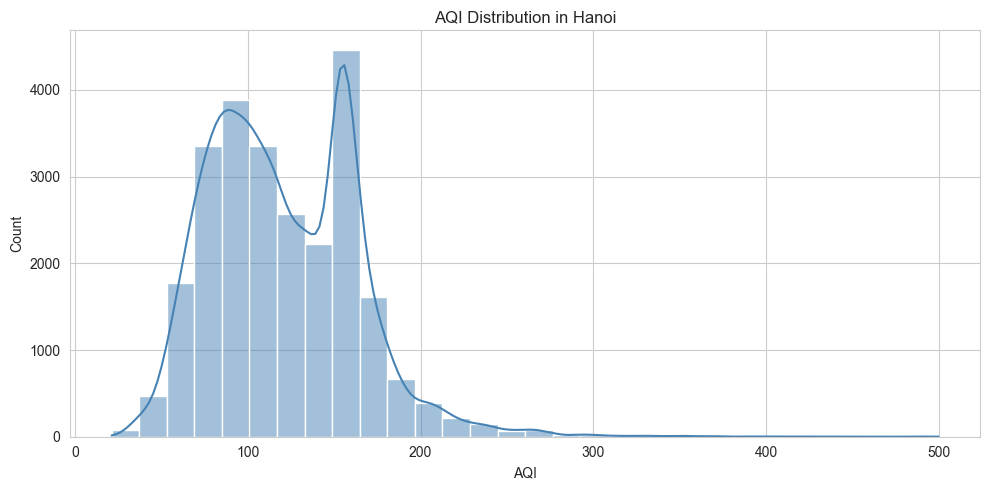

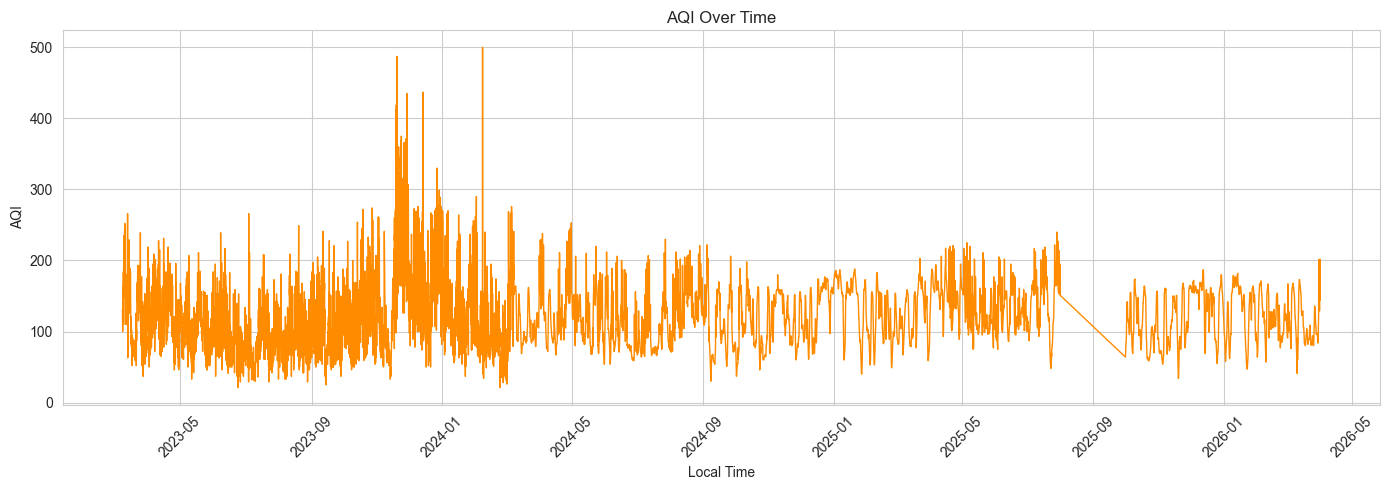

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(raw_df['AQI'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('AQI Distribution in Hanoi')
plt.xlabel('AQI')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
time_df = raw_df.copy()
time_df['Local Time'] = pd.to_datetime(time_df['Local Time'])
time_df = time_df.sort_values('Local Time')

plt.plot(time_df['Local Time'], time_df['AQI'], color='darkorange', linewidth=1)
plt.title('AQI Over Time')
plt.xlabel('Local Time')
plt.ylabel('AQI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. AQI by Hour and Weekday

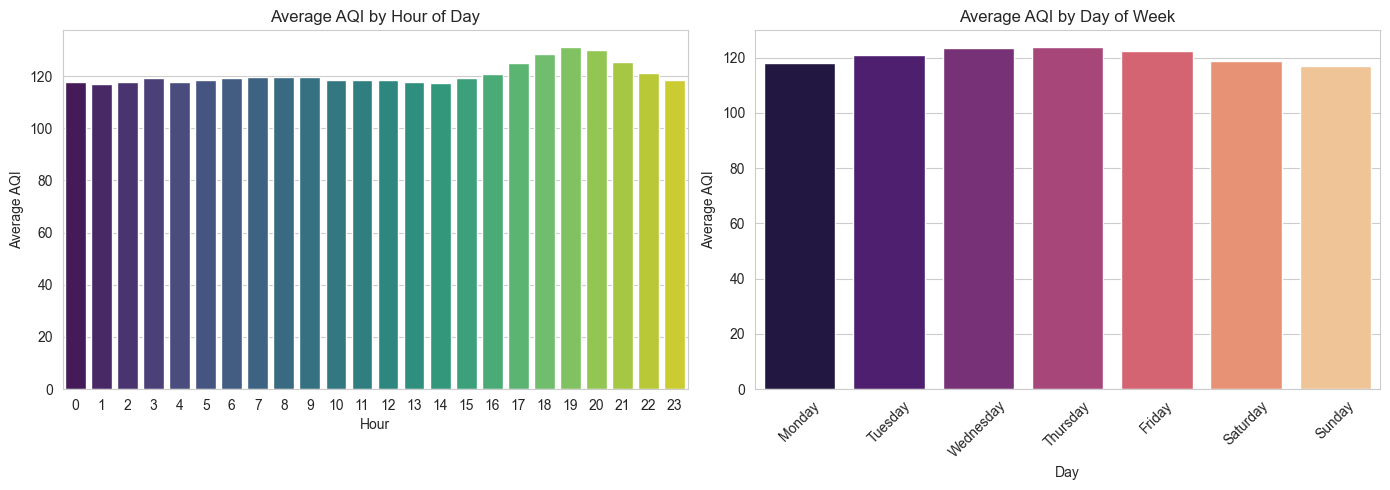

In [14]:
raw_df['Local Time'] = pd.to_datetime(raw_df['Local Time'])
raw_df['hour'] = raw_df['Local Time'].dt.hour
raw_df['day_of_week'] = raw_df['Local Time'].dt.day_name()

hourly_aqi = raw_df.groupby('hour')['AQI'].mean().reset_index()
weekday_aqi = raw_df.groupby('day_of_week')['AQI'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).reset_index()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=hourly_aqi, x='hour', y='AQI', palette='viridis')
plt.title('Average AQI by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average AQI')

plt.subplot(1, 2, 2)
sns.barplot(data=weekday_aqi, x='day_of_week', y='AQI', palette='magma')
plt.title('Average AQI by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 8. Correlation Heatmap

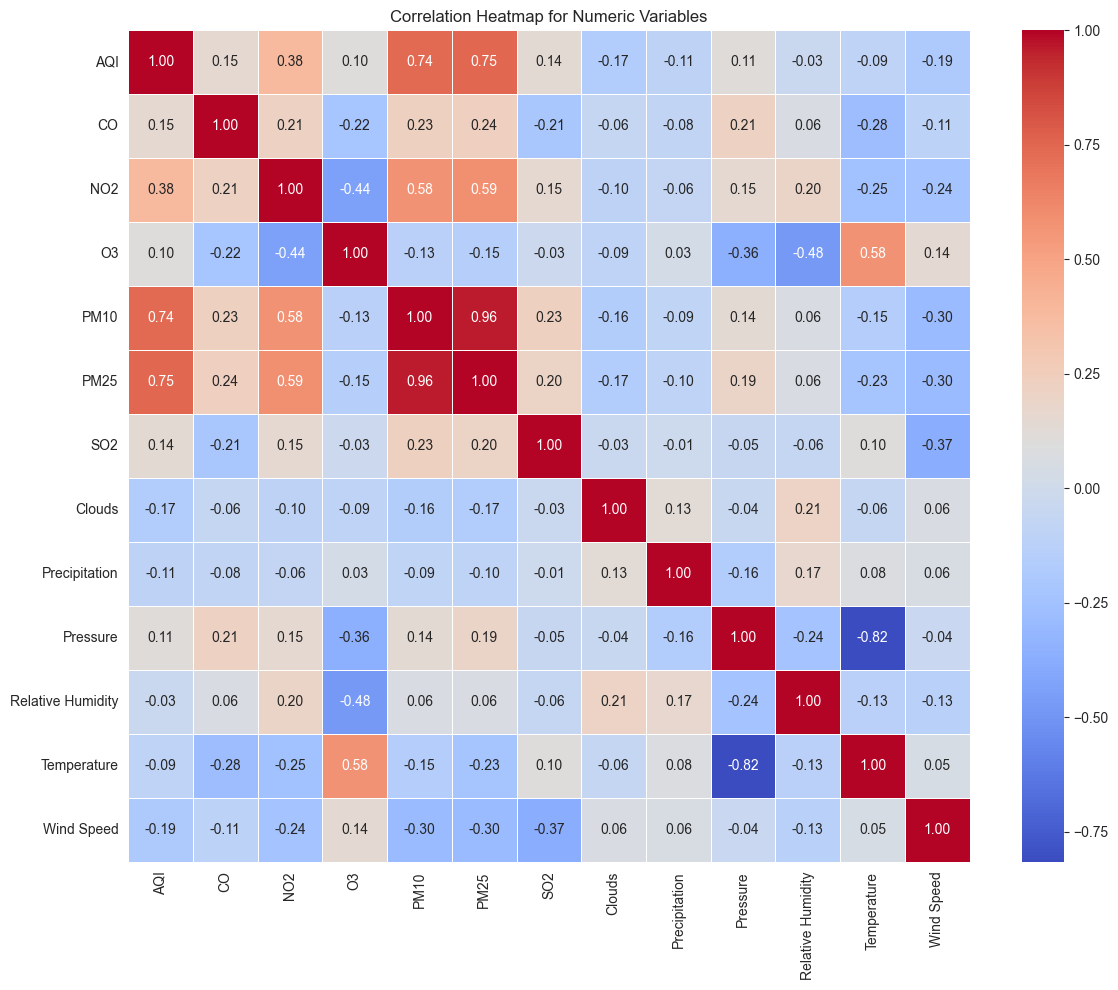

In [15]:
numeric_df = raw_df.select_dtypes(include=['float64', 'int64']).copy()

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Numeric Variables')
plt.tight_layout()
plt.show()

## 9. AQI Outlier Analysis

In [16]:
q1 = raw_df['AQI'].quantile(0.25)
q3 = raw_df['AQI'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = raw_df[(raw_df['AQI'] < lower_bound) | (raw_df['AQI'] > upper_bound)]

print(f'Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}')
print('Number of AQI outliers:', len(outliers))

Lower bound: -12.00, Upper bound: 252.00
Number of AQI outliers: 200


## 10. Engineered Feature Review

In [17]:
print("Base features used in modeling:\n")
print(base_feature_names)

print("\nInteraction features created:\n")
print(interaction_feature_names)

print("\nNumber of polynomial feature outputs:", len(feature_names))

df_clean[['Local Time', 'AQI', 'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_24', 'hour', 'day_of_week']].head()

Base features used in modeling:

['Temperature', 'Relative Humidity', 'Wind Speed', 'Precipitation', 'hour', 'day_of_week', 'PM25', 'PM10', 'CO', 'NO2', 'O3', 'SO2', 'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_24']

Interaction features created:

['temp_humidity', 'pm25_wind']

Number of polynomial feature outputs: 170


,Local Time,AQI,AQI_lag_1,AQI_lag_3,AQI_lag_24,hour,day_of_week
0,2023-03-09 00:00:00,161,181.0,184.0,131.0,0,3
1,2023-03-09 01:00:00,167,161.0,167.0,126.0,1,3
2,2023-03-09 02:00:00,169,167.0,181.0,118.0,2,3
3,2023-03-09 03:00:00,200,169.0,161.0,126.0,3,3
4,2023-03-09 04:00:00,195,200.0,167.0,118.0,4,3


## 11. AQI Category Table

In [18]:
raw_df['AQI_Category'] = classify_aqi(raw_df['AQI'])
category_counts = raw_df['AQI_Category'].value_counts().reset_index()
category_counts.columns = ['AQI Category', 'Count']

category_counts

,AQI Category,Count
0,Moderate (51-100),9125
1,Unhealthy for Sensitive Groups (101-150),8499
2,Unhealthy (151-200),6461
3,Very Unhealthy (201-300),845
4,Good (0-50),431
5,Hazardous (301+),55


## 12. AQI Category Distribution Plot

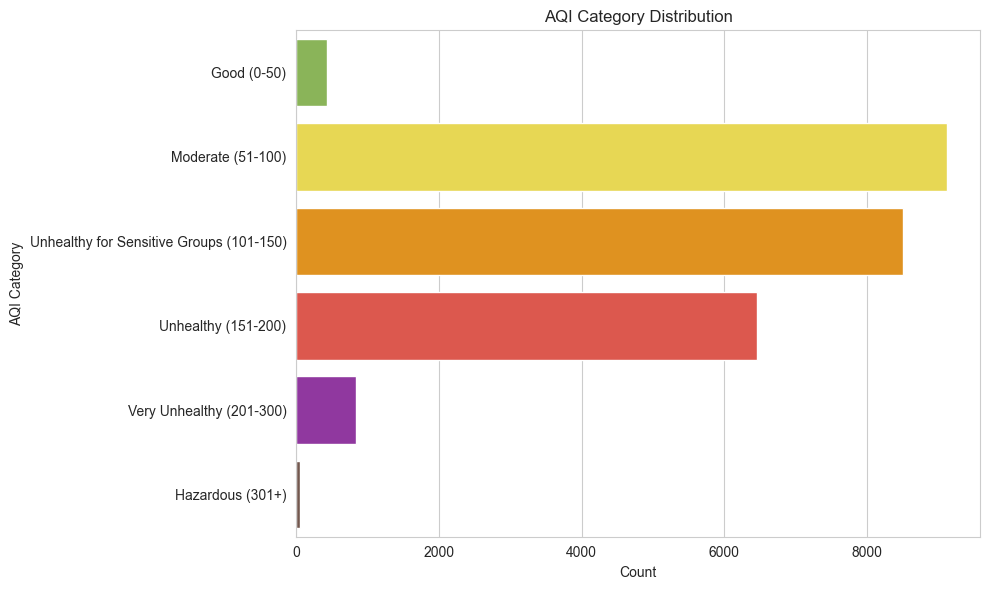

,AQI Category,Count
0,Good (0-50),431
1,Moderate (51-100),9125
2,Unhealthy for Sensitive Groups (101-150),8499
3,Unhealthy (151-200),6461
4,Very Unhealthy (201-300),845
5,Hazardous (301+),55


In [19]:
raw_df['AQI_Category'] = classify_aqi(raw_df['AQI'])

aqi_order = [
    'Good (0-50)',
    'Moderate (51-100)',
    'Unhealthy for Sensitive Groups (101-150)',
    'Unhealthy (151-200)',
    'Very Unhealthy (201-300)',
    'Hazardous (301+)'
]

category_counts = raw_df['AQI_Category'].value_counts().reindex(aqi_order).reset_index()
category_counts.columns = ['AQI Category', 'Count']
category_counts['Count'] = category_counts['Count'].fillna(0).astype(int)

plt.figure(figsize=(10, 6))
sns.countplot(
    data=raw_df,
    y='AQI_Category',
    order=aqi_order,
    palette=['#8bc34a', '#ffeb3b', '#ff9800', '#f44336', '#9c27b0', '#795548']
)
plt.title('AQI Category Distribution')
plt.xlabel('Count')
plt.ylabel('AQI Category')
plt.tight_layout()
plt.show()

category_counts

The dataset often shows imbalance across categories: common cases such as Moderate and Unhealthy for Sensitive Groups dominate the historical data, while Hazardous events are much rarer. This imbalance means the model should be evaluated carefully on high-AQI conditions rather than relying only on overall error metrics.

## 13. Scikit-Learn Linear Regression

In [20]:
sklearn_model = train_sklearn_model(X_train, y_train)

print("Scikit-learn model training completed.")
print("Number of features learned:", sklearn_model.coef_.shape[0])

Scikit-learn model training completed.
Number of features learned: 170


## 14. Scratch Linear Regression

In [21]:
scratch_model = LinearRegressionScratch(learning_rate=0.01, iterations=1000)
scratch_model.fit(X_train, y_train, X_val=X_valid, y_val=y_valid)

print('Scratch model training completed.')
print(f'Final training cost: {scratch_model.cost_history[-1]:.4f}')

if scratch_model.val_cost_history:
    print(f'Final validation cost: {scratch_model.val_cost_history[-1]:.4f}')

Scratch model training completed.
Final training cost: 113.7754
Final validation cost: 63.6930


## 15. Model Performance Comparison

In [22]:
scratch_val_preds = scratch_model.predict(X_valid)
sklearn_val_preds = sklearn_model.predict(X_valid)

scratch_test_preds = scratch_model.predict(X_test)
sklearn_test_preds = sklearn_model.predict(X_test)

print("===============================")
print("     VALIDATION SET METRICS    ")
print("===============================")
print_metrics('Scratch Linear Regression', calculate_metrics(y_valid, scratch_val_preds))
print_metrics('Scikit-Learn Linear Regression', calculate_metrics(y_valid, sklearn_val_preds))

print("===============================")
print("        TEST SET METRICS       ")
print("===============================")

scratch_metrics = calculate_metrics(y_test, scratch_test_preds)
sklearn_metrics = calculate_metrics(y_test, sklearn_test_preds)

print_metrics('Scratch Linear Regression', scratch_metrics)
print_metrics('Scikit-Learn Linear Regression', sklearn_metrics)

scratch_preds = scratch_test_preds
sklearn_preds = sklearn_test_preds

     VALIDATION SET METRICS    
[Scratch Linear Regression] Metrics:
  MAE: 8.4191
  MSE: 127.3860
  RMSE: 11.2865
  R2: 0.8960

[Scikit-Learn Linear Regression] Metrics:
  MAE: 10.3563
  MSE: 197.3972
  RMSE: 14.0498
  R2: 0.8388

        TEST SET METRICS       
[Scratch Linear Regression] Metrics:
  MAE: 8.1192
  MSE: 109.2221
  RMSE: 10.4509
  R2: 0.9104

[Scikit-Learn Linear Regression] Metrics:
  MAE: 7.3225
  MSE: 99.0007
  RMSE: 9.9499
  R2: 0.9188



## 16. Plot Scratch Model Cost Over Iterations

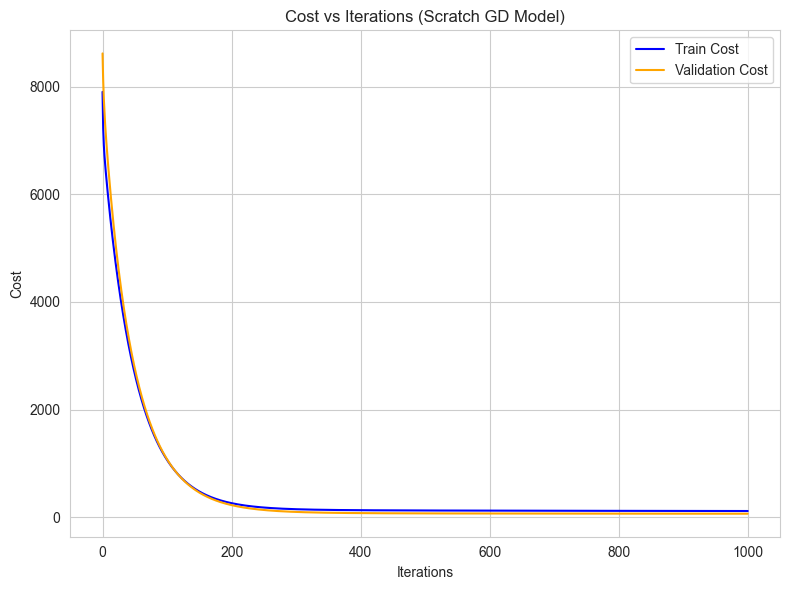

In [23]:
plt.figure(figsize=(8, 6))
plt.plot(range(len(scratch_model.cost_history)), scratch_model.cost_history, color='blue', label='Train Cost')

if scratch_model.val_cost_history:
    plt.plot(range(len(scratch_model.val_cost_history)), scratch_model.val_cost_history, color='orange', label='Validation Cost')

plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Cost vs Iterations (Scratch GD Model)')
plt.legend()
plt.tight_layout()
plt.show()

The scratch model uses gradient descent, which may converge more slowly and be sensitive to learning rate. The scikit-learn implementation uses an optimized closed-form solver under the hood, so it often achieves more stable results for linear regression on this engineered feature set.

## 17. Real-Time AQI Prediction

In [28]:
def create_interaction_features_realtime(base_features):
    base_features = list(base_features)

    temperature = base_features[0]
    humidity = base_features[1]
    wind_speed = base_features[2]
    pm25 = base_features[6]

    temp_humidity = temperature * humidity
    pm25_wind = pm25 * wind_speed

    full_features = base_features + [temp_humidity, pm25_wind]
    return np.array([full_features])

def realtime_aqi_prediction(model, scaler, poly_transformer):
    realtime_features_raw = fetch_realtime_data()
    realtime_features = create_interaction_features_realtime(realtime_features_raw[0])
    realtime_poly = poly_transformer.transform(realtime_features)
    realtime_scaled = scaler.transform(realtime_poly)

    print("Feature shape for prediction:", realtime_scaled.shape)
    assert realtime_scaled.shape[1] == model.n_features_in_

    predicted_aqi = model.predict(realtime_scaled)[0]
    category = classify_aqi(predicted_aqi)

    return predicted_aqi, category, realtime_features


try:
    required_vars = ['sklearn_model', 'data_dict']
    missing = [var for var in required_vars if var not in globals()]
    if missing:
        raise NameError(f"Required variables not defined: {missing}. Please run the preprocessing and model training cells first.")

    predicted_aqi, category, realtime_features = realtime_aqi_prediction(
        sklearn_model,
        data_dict['scaler'],
        data_dict['poly_transformer']
    )

    now = datetime.now()
    latitude = 21.0285
    longitude = 105.8542

    print("\n" + "=" * 50)
    print("--- HANOI LIVE AQI PREDICTION REPORT ---")
    print("=" * 50)
    print(f"Location:  Hanoi ({latitude}, {longitude})")
    print(f"Date:      {now.strftime('%d/%m/%Y')}")
    print(f"Time:      {now.strftime('%H:%M')}")
    print("-" * 50)
    print(f"AQI Score: {predicted_aqi:.2f}")
    print(f"Category:  {category.upper()}")
    print("=" * 50)

    realtime_features

except Exception as e:
    print(f"Error occurred: {e}")

Feature shape for prediction: (1, 170)

--- HANOI LIVE AQI PREDICTION REPORT ---
Location:  Hanoi (21.0285, 105.8542)
Date:      06/04/2026
Time:      22:38
--------------------------------------------------
AQI Score: 186.35
Category:  UNHEALTHY (151-200)
